In [5]:
from skfem import *
from skfem.models.elasticity import linear_elasticity, linear_stress
from skfem.helpers import ddot, grad, sym_grad, identity, transpose
import numpy as np
import matplotlib.pyplot as plt

# 1. Mesh
L, W, t = 1.0, 1.0, 0.01
nx, ny, nz = 20, 20, 5
m = MeshTet.init_tensor(np.linspace(0, L, nx),
                        np.linspace(0, W, ny),
                        np.linspace(0, t, nz))
basis = Basis(m, ElementVectorH1(ElementTetP1()))

# 2. Material constants
E = 70e9  # Young’s modulus [Pa]
nu = 0.3  # Poisson ratio

# 3. Lamé parameters
lam = E * nu / ((1 + nu) * (1 - 2 * nu))
mu = E / (2 * (1 + nu))

# 4. Pre-strain 함수
def eps0(w):
    # w.x.shape = (3, npoints) for 3D
    # 예: z 위치에 따라 응력을 선형으로 변화
    z = w.x[2]
    strain = np.zeros((3, 3, z.size))
    strain[2, 2] = -1e-3 * (1 + 0.5 * np.sin(np.pi * z / z.max()))  # z 방향 비균일 수축
    return strain

@LinearForm
def rhs(v, w):
    ε0 = eps0(w)  # shape (3,3,npoints)
    σ0 = lam * np.trace(ε0, axis1=0, axis2=1) * np.eye(3)[:, :, None] + 2 * mu * ε0
    return ddot(σ0, sym_grad(v))

# 5. 전체 에너지 (비선형 변형이 더 정확하긴 하나 선형도 가능)
@BilinearForm
def bilinf(u, v, w):
    return ddot(lam * np.trace(sym_grad(u)) * identity(3) + 2 * mu * sym_grad(u), sym_grad(v))

# 6. 경계 고정 (예: 아래 z=0 면 고정)
fixed = basis.get_dofs(lambda x: x[2] < 1e-6)

# 7. 조립 & 풀기
A = asm(bilinf, basis)
b = asm(rhs, basis)
x = solve(*condense(A, b, D=fixed))

# 8. 시각화 (z 변위만)
from skfem.visuals.matplotlib import plot
plot(basis, x[2::3])  # z변위 성분만
plt.title("Out-of-plane displacement")
plt.show()


AttributeError: 'int' object has no attribute 'shape'

<Axes3D: >

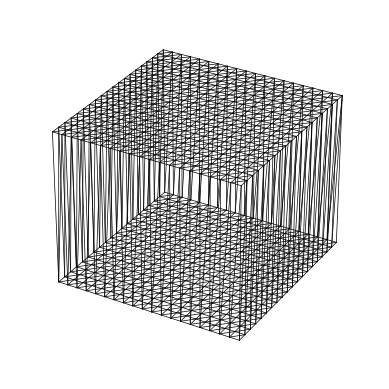

In [3]:
m.draw()